In [2]:
"""
# 08 — Comparación de Optimizadores

"Módulo:" 05 — Deep Learning para Clasificación  
"Framework:" TensorFlow / Keras  
"Dataset:" MNIST
---
## ¿Qué vamos a aprender en este notebook?
1. Qué es un optimizador y qué rol cumple en el entrenamiento
2. Cómo funcionan SGD, Adam y RMSprop intuitivamente
3. Qué es el learning rate y por qué es el hiperparámetro más importante
4. Comparar los optimizadores en velocidad de convergencia y accuracy final
5. Cómo usar un learning rate scheduler para mejorar el entrenamiento
---
El optimizador es el algoritmo que actualiza los pesos de la red
durante el entrenamiento — elegir el correcto puede ser la diferencia
entre un modelo que converge rápido y uno que no converge nunca.

## 1. ¿Qué es un optimizador?

Durante el entrenamiento la red comete errores medidos por la "loss function".
El optimizador es el algoritmo que usa esos errores para "actualizar los pesos"
en la dirección que reduce la loss.
Loss alta
↓
Calcular gradientes (backpropagation)
↓
Optimizador actualiza los pesos
↓
Loss más baja
↓
Repetir hasta converger

### El learning rate — el hiperparámetro más importante
El learning rate (LR) controla "cuánto se actualizan los pesos" en cada paso:
LR muy alto:   pesos ──────────────────→ overshooting, no converge
LR apropiado:  pesos ────→ converge bien
LR muy bajo:   pesos →   converge muy lento o se estanca
| Learning Rate | Efecto |
|---|---|
| 0.1 | Demasiado alto — oscila o diverge |
| 0.01 | Alto — converge rápido pero puede oscilar |
| 0.001 | Estándar para Adam — buen punto de partida |
| 0.0001 | Bajo — converge lento pero estable |

## 2. Los tres optimizadores principales

### SGD — Stochastic Gradient Descent
El más simple y clásico. Actualiza los pesos en la dirección
del gradiente con un paso fijo.
w = w - lr × gradiente
- "Ventaja": simple, predecible, bien entendido teóricamente
- "Desventaja": lento, sensible al learning rate, puede quedarse
  atascado en mínimos locales
- "Variante": SGD con momentum — acumula velocidad en la dirección
  correcta como una pelota rodando cuesta abajo
### RMSprop — Root Mean Square Propagation
Adapta el learning rate de cada peso individualmente según
la magnitud de sus gradientes recientes.
- "Ventaja": maneja bien gradientes que varían mucho entre capas
- "Desventaja": puede ser inestable al final del entrenamiento
- "Uso típico": redes recurrentes (RNNs)
### Adam — Adaptive Moment Estimation
Combina las ideas de SGD con momentum y RMSprop.
Adapta el LR individualmente Y acumula momento.
- "Ventaja": converge rápido, robusto, pocas veces falla
- "Desventaja": puede generalizar levemente peor que SGD en algunos casos
- "Uso típico": punto de partida recomendado para casi cualquier problema

"""

'\n# 08 — Comparación de Optimizadores\n\n"Módulo:" 05 — Deep Learning para Clasificación  \n"Framework:" TensorFlow / Keras  \n"Dataset:" MNIST\n---\n## ¿Qué vamos a aprender en este notebook?\n1. Qué es un optimizador y qué rol cumple en el entrenamiento\n2. Cómo funcionan SGD, Adam y RMSprop intuitivamente\n3. Qué es el learning rate y por qué es el hiperparámetro más importante\n4. Comparar los optimizadores en velocidad de convergencia y accuracy final\n5. Cómo usar un learning rate scheduler para mejorar el entrenamiento\n---\nEl optimizador es el algoritmo que actualiza los pesos de la red\ndurante el entrenamiento — elegir el correcto puede ser la diferencia\nentre un modelo que converge rápido y uno que no converge nunca.\n\n## 1. ¿Qué es un optimizador?\n\nDurante el entrenamiento la red comete errores medidos por la "loss function".\nEl optimizador es el algoritmo que usa esos errores para "actualizar los pesos"\nen la dirección que reduce la loss.\nLoss alta\n↓\nCalcular gr

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.21.0
Keras version: 3.14.0


In [4]:
# Cargar MNIST
(X_train_raw, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar
X_train_raw = X_train_raw.astype('float32') / 255.0
X_test      = X_test.astype('float32')      / 255.0

# Agregar canal
X_train_raw = X_train_raw[..., np.newaxis]
X_test      = X_test[..., np.newaxis]

# Separar validación
X_val   = X_train_raw[50000:]
X_train = X_train_raw[:50000]
y_val   = y_train[50000:]
y_train = y_train[:50000]

# Subconjunto para que el entrenamiento no tarde demasiado
N_TRAIN = 10000
X_train_small = X_train[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]

print(f"Train: {X_train_small.shape[0]} muestras")
print(f"Val:   {X_val.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")


Train: 10000 muestras
Val:   10000 muestras
Test:  10000 muestras


In [5]:
"""
## 3. Arquitectura base
Para comparar los optimizadores de forma justa vamos a usar la "misma arquitectura" para todos los modelos — la única variable que cambia es el optimizador.
Este es un principio fundamental de experimentación en machine learning: cambiar "una sola variable a la vez".
Si cambiamos arquitectura y optimizador al mismo tiempo no podemos saber qué causó la diferencia en los resultados.
"""

'\n## 3. Arquitectura base\nPara comparar los optimizadores de forma justa vamos a usar la "misma arquitectura" para todos los modelos — la única variable que cambia es el optimizador.\nEste es un principio fundamental de experimentación en machine learning: cambiar "una sola variable a la vez".\nSi cambiamos arquitectura y optimizador al mismo tiempo no podemos saber qué causó la diferencia en los resultados.\n'

In [6]:
def build_model(input_shape=(28, 28, 1), num_classes=10):
    """Arquitectura base — igual para todos los optimizadores."""
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Verificar arquitectura
model_test = build_model()
model_test.summary()
print(f"\nParámetros totales: {model_test.count_params():,}")

C:\Users\Peter\ml_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Parámetros totales: 421,642


In [7]:
"""
## 4. Definir los optimizadores a comparar
Vamos a comparar cinco configuraciones:
| Optimizador | Learning Rate | Notas |
|---|---|---|
| "SGD" | 0.01 | Sin momentum — versión más básica |
| "SGD + momentum" | 0.01 | Momentum=0.9 — versión estándar |
| "RMSprop" | 0.001 | LR estándar para RMSprop |
| "Adam" | 0.001 | LR estándar para Adam |
| "Adam LR bajo" | 0.0001 | Para ver el efecto de un LR más conservador |

Los learning rates estándar son distintos para cada optimizador — no se puede comparar SGD con LR=0.001 contra Adam con LR=0.001
 porque cada uno tiene una escala distinta de actualización.
"""

'\n## 4. Definir los optimizadores a comparar\nVamos a comparar cinco configuraciones:\n| Optimizador | Learning Rate | Notas |\n|---|---|---|\n| "SGD" | 0.01 | Sin momentum — versión más básica |\n| "SGD + momentum" | 0.01 | Momentum=0.9 — versión estándar |\n| "RMSprop" | 0.001 | LR estándar para RMSprop |\n| "Adam" | 0.001 | LR estándar para Adam |\n| "Adam LR bajo" | 0.0001 | Para ver el efecto de un LR más conservador |\n\nLos learning rates estándar son distintos para cada optimizador — no se puede comparar SGD con LR=0.001 contra Adam con LR=0.001\n porque cada uno tiene una escala distinta de actualización.\n'

In [8]:
# Definir optimizadores a comparar
optimizadores = {
    'SGD':              keras.optimizers.SGD(learning_rate=0.01),
    'SGD + momentum':   keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop':          keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':             keras.optimizers.Adam(learning_rate=0.001),
    'Adam LR bajo':     keras.optimizers.Adam(learning_rate=0.0001),
}

histories = {}

for nombre, optimizador in optimizadores.items():
    print(f"Entrenando con {nombre}...")

    model = build_model()
    model.compile(
        optimizer=optimizador,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_small, y_train_small,
        epochs=20,
        batch_size=64,
        validation_data=(X_val, y_val),
        verbose=0
    )

    histories[nombre] = history

    val_acc = history.history['val_accuracy'][-1]
    print(f"  val_accuracy final: {val_acc*100:.1f}% ✓")

print("\nTodos los modelos entrenados.")

Entrenando con SGD...
  val_accuracy final: 95.5% ✓
Entrenando con SGD + momentum...
  val_accuracy final: 97.9% ✓
Entrenando con RMSprop...
  val_accuracy final: 98.4% ✓
Entrenando con Adam...
  val_accuracy final: 98.5% ✓
Entrenando con Adam LR bajo...
  val_accuracy final: 97.7% ✓

Todos los modelos entrenados.


In [9]:
"""
## 5. Visualizar curvas de convergencia

El accuracy final es importante pero las curvas nos muestran algo más valioso: "la velocidad de convergencia".
Prestá atención a:
- Cuántas epochs necesita cada optimizador para llegar al 95%
- Cuál converge más suavemente
- Cuál oscila más durante el entrenamiento
En proyectos reales donde el entrenamiento cuesta horas o días, un optimizador que converge en la mitad de epochs puede significar
un ahorro enorme de tiempo y recursos computacionales.
"""

'\n## 5. Visualizar curvas de convergencia\n\nEl accuracy final es importante pero las curvas nos muestran algo más valioso: "la velocidad de convergencia".\nPrestá atención a:\n- Cuántas epochs necesita cada optimizador para llegar al 95%\n- Cuál converge más suavemente\n- Cuál oscila más durante el entrenamiento\nEn proyectos reales donde el entrenamiento cuesta horas o días, un optimizador que converge en la mitad de epochs puede significar\nun ahorro enorme de tiempo y recursos computacionales.\n'

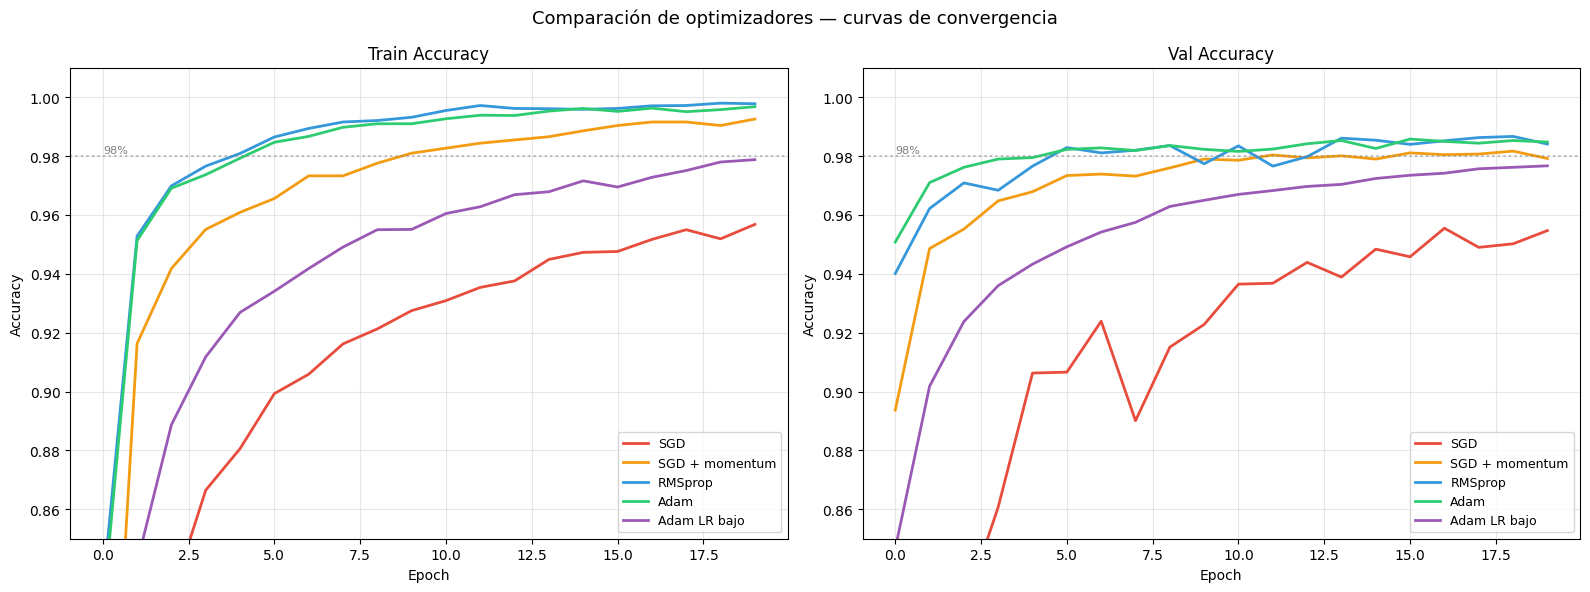

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de optimizadores — curvas de convergencia', fontsize=13)

colores = {
    'SGD':            '#e74c3c',
    'SGD + momentum': '#f39c12',
    'RMSprop':        '#3498db',
    'Adam':           '#2ecc71',
    'Adam LR bajo':   '#9b59b6'
}

for nombre, history in histories.items():
    color = colores[nombre]

    # Train accuracy
    axes[0].plot(history.history['accuracy'],
                 label=nombre, linewidth=2, color=color)

    # Val accuracy
    axes[1].plot(history.history['val_accuracy'],
                 label=nombre, linewidth=2, color=color)

# Línea de referencia en 98%
for ax in axes:
    ax.axhline(y=0.98, color='gray', linestyle=':', alpha=0.5)
    ax.text(0, 0.981, '98%', fontsize=8, color='gray')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.85, 1.01)

axes[0].set_title('Train Accuracy')
axes[1].set_title('Val Accuracy')

plt.tight_layout()
plt.savefig('../figures/08_curvas_optimizadores.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
"""
## 6. Comparación final en test set

Las curvas nos dieron intuición sobre la velocidad de convergencia.
Ahora vamos a evaluar los cinco modelos sobre el test set para tener una comparación definitiva.

Un modelo que converge más rápido no siempre generaliza mejor — la velocidad de convergencia y la calidad final son dos métricas
distintas que hay que evaluar por separado.
"""

'\n## 6. Comparación final en test set\n\nLas curvas nos dieron intuición sobre la velocidad de convergencia.\nAhora vamos a evaluar los cinco modelos sobre el test set para tener una comparación definitiva.\n\nUn modelo que converge más rápido no siempre generaliza mejor — la velocidad de convergencia y la calidad final son dos métricas\ndistintas que hay que evaluar por separado.\n'

Optimizador            Val Accuracy   Val Loss   Epochs→95%
SGD                           95.6%     0.1487           17
SGD + momentum                98.2%     0.0688            3
RMSprop                       98.7%     0.0622            2
Adam                          98.6%     0.0586            1
Adam LR bajo                  97.7%     0.0797            7


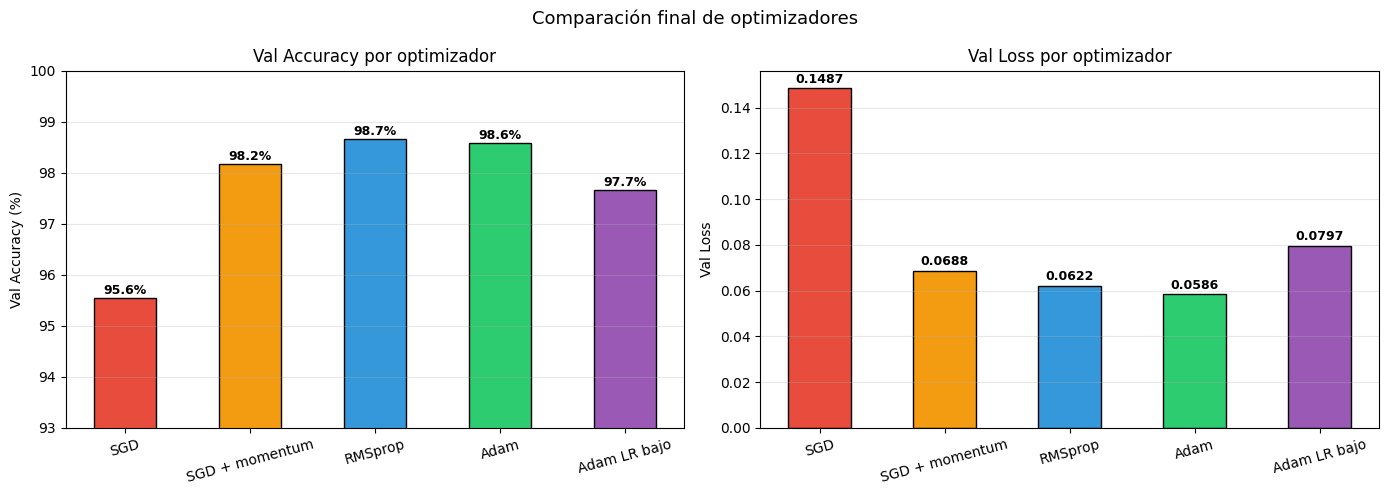

In [12]:
# Re-entrenar cada modelo para evaluación final
# (guardamos los modelos entrenados en el loop anterior)
resultados = {}

for nombre, history in histories.items():
    # Obtener métricas finales de validación
    val_acc  = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])

    # Epochs para llegar al 95% de val accuracy
    accs = history.history['val_accuracy']
    epochs_95 = next((i+1 for i, a in enumerate(accs) if a >= 0.95), None)
    epochs_95_str = str(epochs_95) if epochs_95 else '>20'

    resultados[nombre] = {
        'val_accuracy': val_acc,
        'val_loss':     val_loss,
        'epochs_95':    epochs_95_str
    }

# Tabla comparativa
print("="*65)
print(f"{'Optimizador':<20} {'Val Accuracy':>14} {'Val Loss':>10} {'Epochs→95%':>12}")
print("="*65)
for nombre, res in resultados.items():
    print(f"{nombre:<20} {res['val_accuracy']*100:>13.1f}% "
          f"{res['val_loss']:>10.4f} {res['epochs_95']:>12}")
print("="*65)

# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación final de optimizadores', fontsize=13)

nombres   = list(resultados.keys())
accuracys = [resultados[n]['val_accuracy'] * 100 for n in nombres]
losses    = [resultados[n]['val_loss'] for n in nombres]
colores   = [colores[n] for n in nombres]

# Accuracy
bars = axes[0].bar(nombres, accuracys, color=colores, edgecolor='black', width=0.5)
axes[0].set_ylim(93, 100)
axes[0].set_ylabel('Val Accuracy (%)')
axes[0].set_title('Val Accuracy por optimizador')
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)
for bar, acc in zip(bars, accuracys):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.1f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# Loss
bars2 = axes[1].bar(nombres, losses, color=colores, edgecolor='black', width=0.5)
axes[1].set_ylabel('Val Loss')
axes[1].set_title('Val Loss por optimizador')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{loss:.4f}', ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/08_comparacion_final.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
"""
## 7. Learning Rate Scheduler

Una técnica avanzada es "reducir el learning rate durante el entrenamiento"
— empezar con un LR alto para converger rápido y reducirlo para
afinar los pesos al final.
Epoch 1-10:  LR = 0.001  → convergencia rápida
Epoch 11-20: LR = 0.0001 → afinamiento fino
Epoch 21-30: LR = 0.00001 → ajuste muy fino

### Tipos de schedulers en Keras

| Scheduler | Comportamiento |
|---|---|
| "ReduceLROnPlateau" | Reduce LR cuando la val loss se estanca |
| "ExponentialDecay" | Reduce LR exponencialmente cada N steps |
| "CosineDecay" | Reduce LR siguiendo una curva coseno |

El más práctico para empezar es "ReduceLROnPlateau" porque
se adapta automáticamente al comportamiento del entrenamiento.
"""

'\n## 7. Learning Rate Scheduler\n\nUna técnica avanzada es "reducir el learning rate durante el entrenamiento"\n— empezar con un LR alto para converger rápido y reducirlo para\nafinar los pesos al final.\nEpoch 1-10:  LR = 0.001  → convergencia rápida\nEpoch 11-20: LR = 0.0001 → afinamiento fino\nEpoch 21-30: LR = 0.00001 → ajuste muy fino\n\n### Tipos de schedulers en Keras\n\n| Scheduler | Comportamiento |\n|---|---|\n| "ReduceLROnPlateau" | Reduce LR cuando la val loss se estanca |\n| "ExponentialDecay" | Reduce LR exponencialmente cada N steps |\n| "CosineDecay" | Reduce LR siguiendo una curva coseno |\n\nEl más práctico para empezar es "ReduceLROnPlateau" porque\nse adapta automáticamente al comportamiento del entrenamiento.\n'

Entrenando con Adam + ReduceLROnPlateau...

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 20: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 23: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 26: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 29: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Mejor val_accuracy: 98.7%


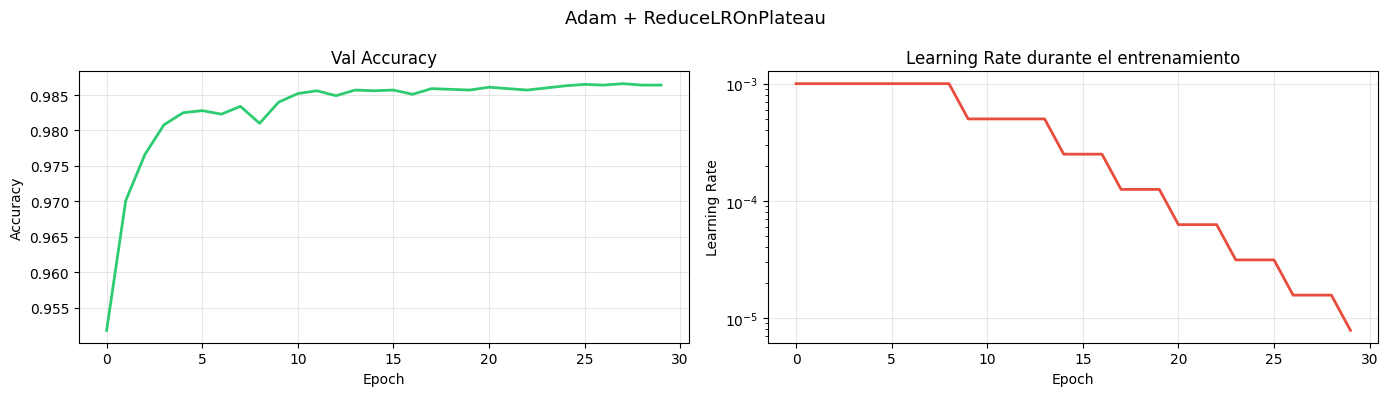

In [14]:
# Modelo con Adam + ReduceLROnPlateau
model_scheduler = build_model()
model_scheduler.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callback que reduce LR cuando val_loss se estanca
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # Reduce LR a la mitad
    patience=3,       # Espera 3 epochs sin mejora
    min_lr=1e-6,      # LR mínimo
    verbose=1
)

print("Entrenando con Adam + ReduceLROnPlateau...")
history_scheduler = model_scheduler.fit(
    X_train_small, y_train_small,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr],
    verbose=0
)

val_acc = max(history_scheduler.history['val_accuracy'])
print(f"\nMejor val_accuracy: {val_acc*100:.1f}%")

# Visualizar el LR a lo largo del entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Adam + ReduceLROnPlateau', fontsize=13)

# Val accuracy
axes[0].plot(history_scheduler.history['val_accuracy'],
             linewidth=2, color='#2ecc71')
axes[0].set_title('Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].grid(alpha=0.3)

# Learning rate
axes[1].plot(history_scheduler.history['learning_rate'],
             linewidth=2, color='#e74c3c')
axes[1].set_title('Learning Rate durante el entrenamiento')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/08_lr_scheduler.png', dpi=120, bbox_inches='tight')
plt.show()

In [16]:
"""
## Resumen del notebook

| Concepto | Lo que aprendimos |
|---|---|
| "SGD" | El más simple — lento y sensible al LR |
| "SGD + momentum" | El momentum acelera dramáticamente la convergencia |
| "RMSprop" | Adaptativo — muy competitivo con Adam |
| "Adam" | El estándar — rápido, robusto y fácil de usar |
| "Learning rate" | El hiperparámetro más importante — afecta velocidad y calidad |
| "ReduceLROnPlateau" | Reduce LR automáticamente cuando el entrenamiento se estanca |
### Recomendaciones prácticas
| Situación | Recomendación |
|---|---|
| Punto de partida | Adam con LR=0.001 |
| Si Adam no converge | Probar RMSprop o reducir LR |
| Si querés mejor generalización | SGD + momentum con LR scheduler |
| Siempre | Usar ReduceLROnPlateau como callback |
---
## ¿Qué sigue?
En el "notebook 09" vamos a estudiar las arquitecturas clásicas
de CNNs — LeNet, VGG y ResNet — entendiendo qué problema resolvió
cada una y por qué fueron tan importantes en la historia del
deep learning.
"""

'\n## Resumen del notebook\n\n| Concepto | Lo que aprendimos |\n|---|---|\n| "SGD" | El más simple — lento y sensible al LR |\n| "SGD + momentum" | El momentum acelera dramáticamente la convergencia |\n| "RMSprop" | Adaptativo — muy competitivo con Adam |\n| "Adam" | El estándar — rápido, robusto y fácil de usar |\n| "Learning rate" | El hiperparámetro más importante — afecta velocidad y calidad |\n| "ReduceLROnPlateau" | Reduce LR automáticamente cuando el entrenamiento se estanca |\n### Recomendaciones prácticas\n| Situación | Recomendación |\n|---|---|\n| Punto de partida | Adam con LR=0.001 |\n| Si Adam no converge | Probar RMSprop o reducir LR |\n| Si querés mejor generalización | SGD + momentum con LR scheduler |\n| Siempre | Usar ReduceLROnPlateau como callback |\n---\n## ¿Qué sigue?\nEn el "notebook 09" vamos a estudiar las arquitecturas clásicas\nde CNNs — LeNet, VGG y ResNet — entendiendo qué problema resolvió\ncada una y por qué fueron tan importantes en la historia del\ndee